In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier

In [4]:
df=pd.read_csv("C:/Users/USER/Desktop/7-cyber_attack_data.csv")

In [5]:
df.head()

,src_packet_rate,dst_packet_rate,avg_payload_size,connection_duration,tcp_flag_count,avg_interarrival_time,failed_login_attempts,unusual_port_activity_score,session_entropy,avg_response_delay,attack_type
0,-1.286132,-0.648334,1.044115,-0.469715,0.789859,-0.083727,-1.647309,-1.316412,1.011910,-0.898063,2
1,-0.222224,2.083232,1.191114,-1.354527,-0.956992,1.696028,-1.070406,0.981403,-1.628798,1.377594,0
2,-0.431963,0.375745,-1.370334,0.819214,0.345243,1.389447,-1.904130,1.292602,0.925545,0.232705,0
3,-0.912633,0.986988,-0.690042,2.014628,-0.442260,0.590347,-1.819353,1.560938,0.823755,0.517762,0
4,-0.367056,1.667892,0.879172,2.214276,1.846338,-0.894047,1.543838,0.931103,-1.015210,1.061845,1


In [6]:
df.columns

Index(['src_packet_rate', 'dst_packet_rate', 'avg_payload_size',
       'connection_duration', 'tcp_flag_count', 'avg_interarrival_time',
       'failed_login_attempts', 'unusual_port_activity_score',
       'session_entropy', 'avg_response_delay', 'attack_type'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   src_packet_rate              1000 non-null   float64
 1   dst_packet_rate              1000 non-null   float64
 2   avg_payload_size             1000 non-null   float64
 3   connection_duration          1000 non-null   float64
 4   tcp_flag_count               1000 non-null   float64
 5   avg_interarrival_time        1000 non-null   float64
 6   failed_login_attempts        1000 non-null   float64
 7   unusual_port_activity_score  1000 non-null   float64
 8   session_entropy              1000 non-null   float64
 9   avg_response_delay           1000 non-null   float64
 10  attack_type                  1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB


In [8]:
df.isnull().sum()

src_packet_rate                0
dst_packet_rate                0
avg_payload_size               0
connection_duration            0
tcp_flag_count                 0
avg_interarrival_time          0
failed_login_attempts          0
unusual_port_activity_score    0
session_entropy                0
avg_response_delay             0
attack_type                    0
dtype: int64

In [9]:
X=df.drop("attack_type",axis=1)
y=df["attack_type"]

In [10]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.3, random_state=15)

In [11]:
model=LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [12]:
y_pred=model.predict(X_test)

In [13]:
score= accuracy_score(y_pred, y_test)
print("score: ", score)
print(classification_report(y_pred, y_test))
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))

score:  0.7866666666666666
              precision    recall  f1-score   support

           0       0.78      0.91      0.84        90
           1       0.74      0.73      0.73        99
           2       0.84      0.74      0.78       111

    accuracy                           0.79       300
   macro avg       0.79      0.79      0.79       300
weighted avg       0.79      0.79      0.79       300

confusion matrix: 
 [[82  2  6]
 [17 72 10]
 [ 6 23 82]]


In [14]:
onevsonemodel=OneVsOneClassifier(LogisticRegression())
onevsonemodel.fit(X_train, y_train)
y_pred=onevsonemodel.predict(X_test)
score= accuracy_score(y_pred, y_test)
print("score: ", score)
print(classification_report(y_pred, y_test))
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))

score:  0.7966666666666666
              precision    recall  f1-score   support

           0       0.80      0.92      0.86        91
           1       0.74      0.76      0.75        95
           2       0.85      0.73      0.78       114

    accuracy                           0.80       300
   macro avg       0.80      0.80      0.80       300
weighted avg       0.80      0.80      0.80       300

confusion matrix: 
 [[84  3  4]
 [12 72 11]
 [ 9 22 83]]


In [15]:
onevsrestmodel=OneVsRestClassifier(LogisticRegression())
onevsrestmodel.fit(X_train, y_train)
y_pred=onevsrestmodel.predict(X_test)
score= accuracy_score(y_pred, y_test)
print("score: ", score)
print(classification_report(y_pred, y_test))
print("confusion matrix: \n", confusion_matrix(y_pred, y_test))

score:  0.7833333333333333
              precision    recall  f1-score   support

           0       0.79      0.91      0.85        91
           1       0.71      0.73      0.72        94
           2       0.85      0.72      0.78       115

    accuracy                           0.78       300
   macro avg       0.78      0.79      0.78       300
weighted avg       0.79      0.78      0.78       300

confusion matrix: 
 [[83  2  6]
 [16 69  9]
 [ 6 26 83]]


In [16]:
#onevsonemodeli kullamıyorum 
coef_matrix = np.array([est.coef_[0] for est in onevsonemodel.estimators_])
mean_coefficients = np.mean(np.abs(coef_matrix), axis=0)


In [17]:
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': mean_coefficients
})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15)

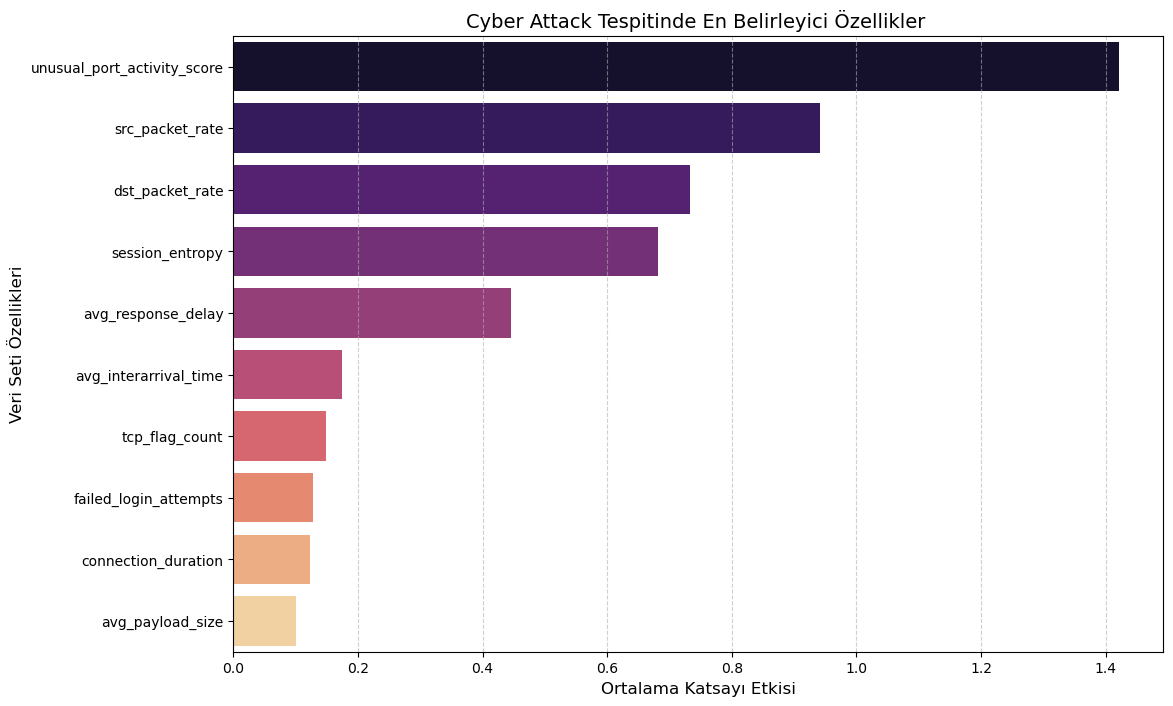

In [25]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='magma', hue='Feature', legend=False)

plt.title('Cyber Attack Tespitinde En Belirleyici Özellikler ', fontsize=14)
plt.xlabel('Ortalama Katsayı Etkisi', fontsize=12)
plt.ylabel('Veri Seti Özellikleri', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.savefig('feature_importance.png')
plt.show()

In [19]:
## Hız ve verimlilik için (Inference Time Analysis) yapacağız.
import time

In [20]:
start_time= time.time()
y_pred=onevsonemodel.predict(X_test)
end_time=time.time()

total_time=end_time- start_time
avg_time_per_sample=total_time/len(X_test)

print(f"toplam tahmin süresi ({len(X_test)} örnek için): {total_time:.4f} saniye")
print(f"Ornek basina ortalama sure: {avg_time_per_sample:.6f} saniye ")

toplam tahmin süresi (300 örnek için): 0.0022 saniye
Ornek basina ortalama sure: 0.000007 saniye 


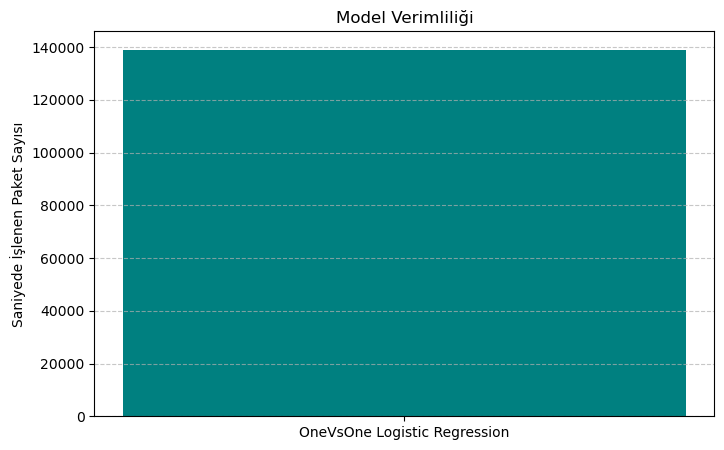

In [26]:
# Saniyede işlenen paket sayısı 
throughput = 1 / avg_time_per_sample

plt.figure(figsize=(8, 5))
plt.bar(['OneVsOne Logistic Regression'], [throughput], color='teal')
plt.title('Model Verimliliği')
plt.ylabel('Saniyede İşlenen Paket Sayısı')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("throughput.png")
plt.show()

In [22]:
## hata analizi
errors = X_test[y_test != y_pred]
actual_labels = y_test[y_test != y_pred]
predicted_labels = y_pred[y_test != y_pred]

error_df = pd.DataFrame({'Gerçek': actual_labels, 'Tahmin': predicted_labels})
print("En çok birbirine karışan sınıflar:\n", error_df.value_counts().head(5))

En çok birbirine karışan sınıflar:
 Gerçek  Tahmin
1       2         22
0       1         12
2       1         11
0       2          9
2       0          4
Name: count, dtype: int64


In [23]:
## Hataları Filtreleme ve Analiz
X_test_with_results = X_test.copy()
X_test_with_results['Gerçek'] = y_test
X_test_with_results['Tahmin'] = y_pred

hata_grubu = X_test_with_results[(X_test_with_results['Gerçek'] == 2) & (X_test_with_results['Tahmin'] == 22)]

# Bu hatalı grubun özellik ortalamalarını tüm veri ortalamasıyla kıyasliyoruz
analiz = pd.DataFrame({
    'Hatalı Örneklerin Ortalaması': hata_grubu.mean(),
    'Tüm Test Setinin Ortalaması': X_test.mean()
})

# Aradaki fark
analiz['Fark'] = analiz['Hatalı Örneklerin Ortalaması'] - analiz['Tüm Test Setinin Ortalaması']
print(analiz.sort_values(by='Fark', ascending=False).head(5))

                       Hatalı Örneklerin Ortalaması  \
Gerçek                                          NaN   
Tahmin                                          NaN   
avg_interarrival_time                           NaN   
avg_payload_size                                NaN   
avg_response_delay                              NaN   

                       Tüm Test Setinin Ortalaması  Fark  
Gerçek                                         NaN   NaN  
Tahmin                                         NaN   NaN  
avg_interarrival_time                     0.033951   NaN  
avg_payload_size                         -0.082807   NaN  
avg_response_delay                        0.175837   NaN  
